In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
health_df = pd.read_csv("../data/uds_data.csv")


health_df.head()

health_df.shape


(558553, 198)

In [ ]:
print(health_df.columns)

Index(['no_show', 'age', 'GENDER', 'RACE', 'ETHNICITY', 'APPT_WEEKDAY',
       'APPT_DAY_PART', 'DURATION', 'BOOK_TO_APPT', 'APPT_SEQ',
       ...
       'r_SE_stt', 'r_COI_stt', 'c5_ED_met', 'c5_HE_met', 'c5_SE_met',
       'c5_COI_met', 'r_ED_met', 'r_HE_met', 'r_SE_met', 'r_COI_met'],
      dtype='str', length=198)


In [ ]:
no_shows = ((health_df['no_show'] == "Yes")).sum()
shows = ((health_df['no_show'] == "No")).sum()

print(no_shows/(shows + no_shows))

0.12363374648421904


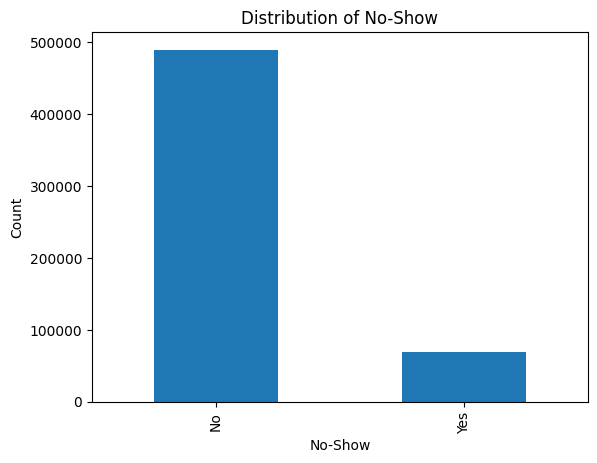

In [ ]:
plt.figure()
health_df["no_show"].value_counts().plot(kind="bar")
plt.title("Distribution of No-Show")
plt.xlabel("No-Show")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

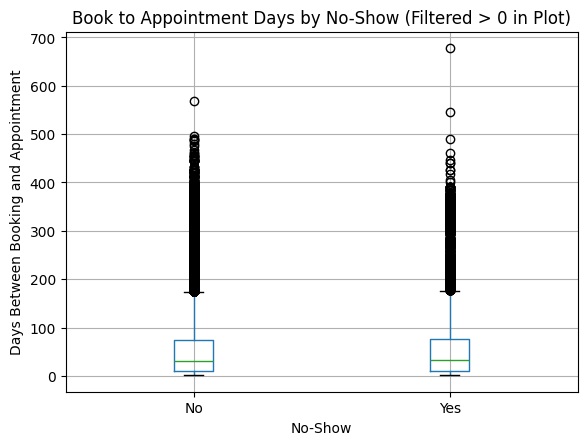

In [ ]:
plt.figure()
#removing all negative days
filtered_data = health_df[health_df["BOOK_TO_APPT"] > 0]
filtered_data.boxplot(column="BOOK_TO_APPT", by="no_show")
plt.title("Book to Appointment Days by No-Show (Filtered > 0 in Plot)")
plt.suptitle("")
plt.xlabel("No-Show")
plt.ylabel("Days Between Booking and Appointment")
plt.show()

<Figure size 640x480 with 0 Axes>

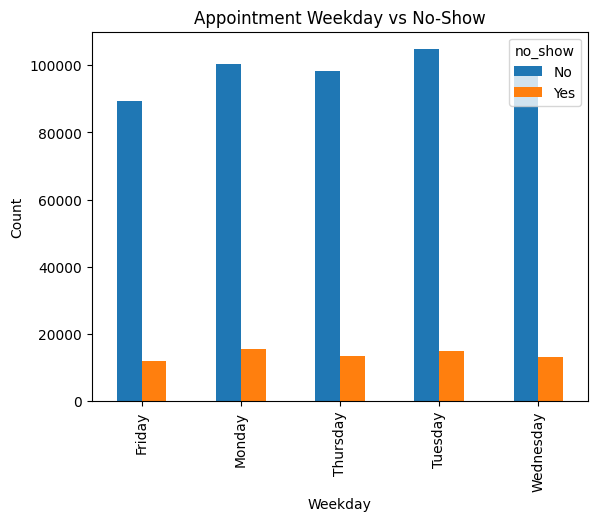

In [ ]:
plt.figure()
pd.crosstab(health_df["APPT_WEEKDAY"], health_df["no_show"]).plot(kind="bar")
plt.title("Appointment Weekday vs No-Show")
plt.xlabel("Weekday")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

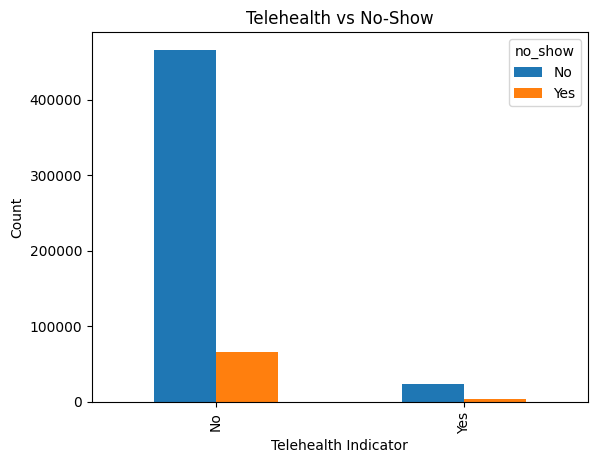

In [ ]:
plt.figure()
pd.crosstab(health_df["TELEHEALTH_IND"], health_df["no_show"]).plot(kind="bar")
plt.title("Telehealth vs No-Show")
plt.xlabel("Telehealth Indicator")
plt.ylabel("Count")
plt.show()

In [7]:
# print(health_df['NOSHOWS_365'].describe())
print(health_df['RPL_THEMES'])

0         0.6235
1         0.7066
2         0.5082
3         0.9801
4         0.1569
           ...  
558548    0.1407
558549       NaN
558550    0.8076
558551    0.8355
558552    0.2342
Name: RPL_THEMES, Length: 558553, dtype: float64


C:\Users\anony\AppData\Local\Temp\ipykernel_28516\1468026238.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  health_df['behavior_risk'] = pd.cut(health_df['NOSHOWS_365'],
C:\Users\anony\AppData\Local\Temp\ipykernel_28516\1468026238.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  health_df['svi_q'] = pd.qcut(health_df['RPL_THEMES'], 4, labels=['Q1','Q2','Q3','Q4'])


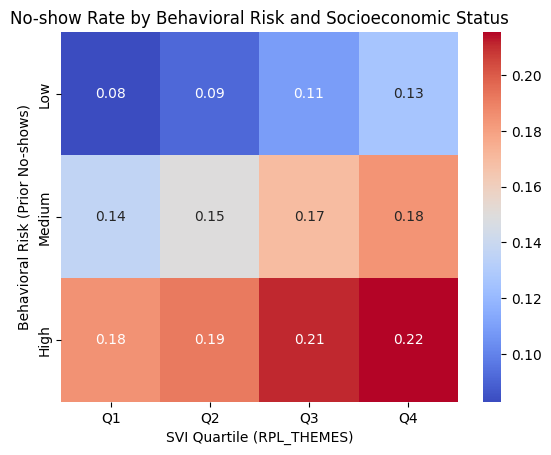

In [23]:
import seaborn as sns

health_df['no_show'] = health_df['no_show'].map({'No': 0, 'Yes': 1})


# Behavioral risk bins
health_df['behavior_risk'] = pd.cut(health_df['NOSHOWS_365'],
                            bins=[-1, 0, 2, 100],
                            labels=['Low', 'Medium', 'High'])

# Socioeconomic quartiles (based on rank)
health_df['svi_q'] = pd.qcut(health_df['RPL_THEMES'], 4, labels=['Q1','Q2','Q3','Q4'])

# heatmap
heatmap_data = health_df.groupby(['behavior_risk', 'svi_q'])['no_show'].mean().unstack()

sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("No-show Rate by Behavioral Risk and Socioeconomic Status")
plt.ylabel("Behavioral Risk (Prior No-shows)")
plt.xlabel("SVI Quartile (RPL_THEMES)")
plt.show()

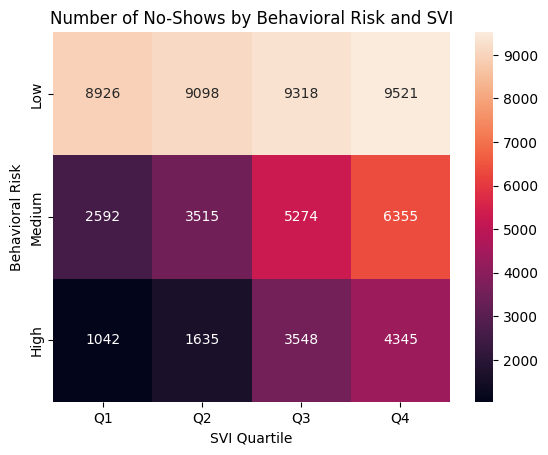

In [ ]:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.unstack.html
# unstack

heatmap_counts = health_df[health_df['no_show'] == 1].groupby(['behavior_risk', 'svi_q'])['no_show'].count().unstack()

sns.heatmap(heatmap_counts, annot=True, fmt="d")
plt.title("Number of No-Shows by Behavioral Risk and SVI")
plt.ylabel("Behavioral Risk")
plt.xlabel("SVI Quartile")
plt.show()